# Baby GPT — Developmental Analysis

Tracks how the model develops over longer training horizons (5m → 15m → 30m → 1h → 2h → 4h → 8h → 12h).

Milestone eval + prompt-pack generation now happens **inside** `train.py` (see `_save_timed_checkpoint`), so no post-run CLI steps are needed — the notebook reads `model_<label>.json` sidecars and `progress.csv` directly from the latest run dir.

A prior-run overlay is supported via `BASELINE_DIR` in the next cell.

In [1]:
import json
import os
import re
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown

HERE = Path(".").resolve()
OUT = HERE / "output"


def _looks_like_run_dir(d: Path) -> bool:
    """A run dir contains training artifacts (checkpoint sidecars, progress.csv,
    or eval_results.csv). Excludes archive dirs and non-run scratch like exports/."""
    if d.name.startswith("_"):
        return False
    if (d / "progress.csv").exists() or (d / "eval_results.csv").exists():
        return True
    return any(d.glob("model_*.json"))


def _latest_run_dir():
    """Return the most recent run-dir subdir under output/.
    Sorted by mtime (most recently written run wins) with name as tiebreaker."""
    if not OUT.is_dir():
        return OUT
    candidates = [d for d in OUT.iterdir() if d.is_dir() and _looks_like_run_dir(d)]
    if not candidates:
        return OUT
    candidates.sort(key=lambda d: (d.stat().st_mtime, d.name), reverse=True)
    return candidates[0]


RUN_DIR = _latest_run_dir()
print(f"RUN_DIR: {RUN_DIR}")

# Optional baseline run to overlay against (yesterday's dedicated 5m-4h sweep).
BASELINE_DIR = OUT / "2026-04-17_phase2_baseline"
if not BASELINE_DIR.is_dir() or BASELINE_DIR == RUN_DIR:
    BASELINE_DIR = None
print(f"BASELINE: {BASELINE_DIR}")

LABELS = ["5m", "15m", "30m", "1h", "2h", "4h", "8h", "12h"]
LABEL_S = {
    "5m": 300,
    "15m": 900,
    "30m": 1800,
    "1h": 3600,
    "2h": 7200,
    "4h": 14400,
    "8h": 28800,
    "12h": 43200,
}
COLORS = [
    "#4e79a7",
    "#f28e2b",
    "#e15759",
    "#76b7b2",
    "#59a14f",
    "#b07aa1",
    "#ff9da7",
    "#9c755f",
]
COLOR_OF = {l: c for l, c in zip(LABELS, COLORS)}


def _eval_df_from_dir(run_dir):
    """Build the (label, elapsed_seconds, num_steps, train_loss_ema, val_bpb) table
    from JSON sidecars. Falls back to eval_results.csv if present and non-empty."""
    if run_dir is None or not Path(run_dir).is_dir():
        return pd.DataFrame()
    csv = Path(run_dir) / "eval_results.csv"
    if csv.exists():
        try:
            df = pd.read_csv(csv)
            if len(df) > 0:
                return df
        except Exception:
            pass
    rows = []
    for label in LABELS:
        meta = Path(run_dir) / f"model_{label}.json"
        if not meta.exists():
            continue
        try:
            d = json.loads(meta.read_text())
        except Exception:
            continue
        rows.append(
            {
                "label": label,
                "elapsed_seconds": d.get("elapsed_seconds"),
                "num_steps": d.get("num_steps"),
                "train_loss_ema": d.get("train_loss_ema"),
                "val_bpb": d.get("val_bpb"),
            }
        )
    return pd.DataFrame(rows)


plt.rcParams.update(
    {"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False}
)

RUN_DIR: C:\Dev\AI\Training\autoresearch\output\2026-04-17_12h_run
BASELINE: C:\Dev\AI\Training\autoresearch\output\2026-04-17_phase2_baseline


## 1. Checkpoint Inventory

In [2]:
# Load JSON sidecars for all found checkpoints
rows = []
for label in LABELS:
    pt = RUN_DIR / f"model_{label}.pt"
    meta = RUN_DIR / f"model_{label}.json"
    if not pt.exists():
        continue
    d = {"label": label, "pt_size_mb": round(pt.stat().st_size / 1e6, 1)}
    if meta.exists():
        d.update(json.loads(meta.read_text()))
    rows.append(d)

inventory = pd.DataFrame(rows)
print(f"Found {len(inventory)} checkpoint(s)")
display(
    inventory[
        [
            c
            for c in [
                "label",
                "elapsed_seconds",
                "num_steps",
                "train_loss_ema",
                "val_bpb",
                "pt_size_mb",
            ]
            if c in inventory.columns
        ]
    ]
)

Found 8 checkpoint(s)


,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,pt_size_mb
0,5m,300.0,1190,3.558503,1.267107,90.2
1,15m,900.1,3659,3.419825,1.212581,90.2
2,30m,1800.0,7427,3.355383,1.192813,90.2
3,1h,3600.1,15020,3.310475,1.178145,90.2
4,2h,7200.0,28963,3.277459,1.169051,90.2
5,4h,14400.3,54733,3.252445,1.162881,90.2
6,8h,28800.1,112929,3.138580,1.122275,90.2
7,12h,43200.2,174682,2.928807,1.043514,90.2


## 2. Developmental Curve — val_bpb & train loss vs time

,label,elapsed_seconds,num_steps,train_loss_ema,val_bpb,elapsed_min
0,5m,300.0,1190,3.558503,1.267107,5.000000
1,15m,900.1,3659,3.419825,1.212581,15.001667
2,30m,1800.0,7427,3.355383,1.192813,30.000000
3,1h,3600.1,15020,3.310475,1.178145,60.001667
4,2h,7200.0,28963,3.277459,1.169051,120.000000
5,4h,14400.3,54733,3.252445,1.162881,240.005000
6,8h,28800.1,112929,3.138580,1.122275,480.001667
7,12h,43200.2,174682,2.928807,1.043514,720.003333


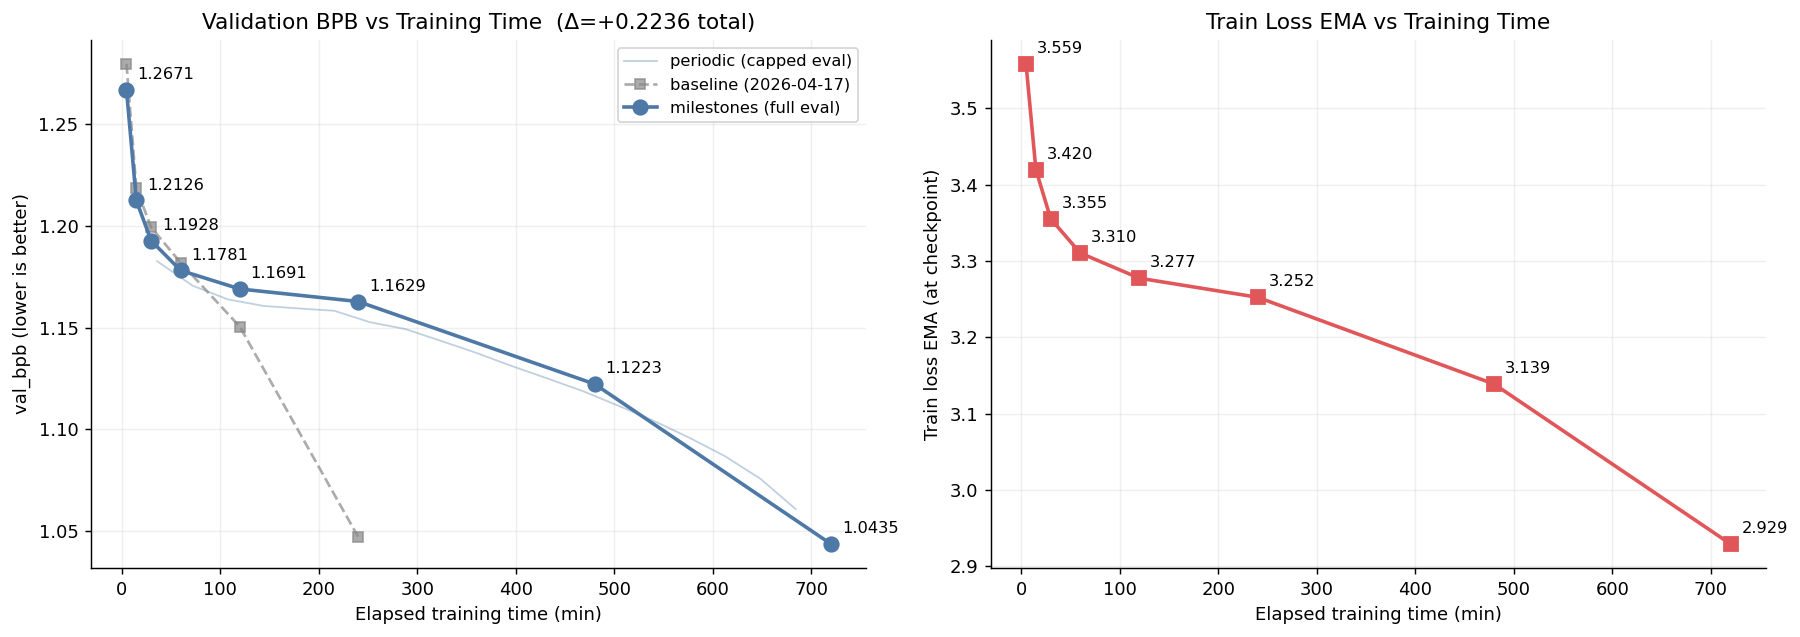

Saved output/developmental_curve.png


In [3]:
# Build eval_df from JSON sidecars (or eval_results.csv if present).
eval_df = _eval_df_from_dir(RUN_DIR)
if eval_df.empty:
    print("No milestone checkpoints found in RUN_DIR yet.")
else:
    eval_df["elapsed_min"] = (
        pd.to_numeric(eval_df["elapsed_seconds"], errors="coerce") / 60
    )
    eval_df["val_bpb"] = pd.to_numeric(eval_df["val_bpb"], errors="coerce")
    eval_df["train_loss_ema"] = pd.to_numeric(
        eval_df["train_loss_ema"], errors="coerce"
    )
    display(eval_df)

# Optional dense periodic curve (progress.csv) written by train.py every ~5% of progress.
progress_csv = RUN_DIR / "progress.csv"
progress_df = pd.read_csv(progress_csv) if progress_csv.exists() else pd.DataFrame()
if not progress_df.empty:
    progress_df["elapsed_min"] = (
        pd.to_numeric(progress_df["elapsed_seconds"], errors="coerce") / 60
    )
    progress_df["val_bpb_capped"] = pd.to_numeric(
        progress_df["val_bpb_capped"], errors="coerce"
    )

# Optional baseline for side-by-side overlay.
baseline_df = _eval_df_from_dir(BASELINE_DIR)
if not baseline_df.empty:
    baseline_df["elapsed_min"] = (
        pd.to_numeric(baseline_df["elapsed_seconds"], errors="coerce") / 60
    )
    baseline_df["val_bpb"] = pd.to_numeric(baseline_df["val_bpb"], errors="coerce")
    baseline_df["train_loss_ema"] = pd.to_numeric(
        baseline_df["train_loss_ema"], errors="coerce"
    )

if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- val_bpb ---
    ax = axes[0]
    # Dense periodic curve (capped eval) behind the milestone markers
    if not progress_df.empty:
        ax.plot(
            progress_df["elapsed_min"],
            progress_df["val_bpb_capped"],
            linewidth=1,
            color="#4e79a7",
            alpha=0.35,
            label="periodic (capped eval)",
        )
    # Optional baseline curve for comparison
    if not baseline_df.empty:
        ax.plot(
            baseline_df["elapsed_min"],
            baseline_df["val_bpb"],
            marker="s",
            linestyle="--",
            linewidth=1.5,
            color="#888",
            markersize=6,
            alpha=0.7,
            label="baseline (2026-04-17)",
        )
    ax.plot(
        eval_df["elapsed_min"],
        eval_df["val_bpb"],
        marker="o",
        linewidth=2,
        color="#4e79a7",
        markersize=8,
        label="milestones (full eval)",
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["val_bpb"]):
            ax.annotate(
                f"{row['val_bpb']:.4f}",
                (row["elapsed_min"], row["val_bpb"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax.set_xlabel("Elapsed training time (min)")
    ax.set_ylabel("val_bpb (lower is better)")
    ax.set_title("Validation BPB vs Training Time")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper right", fontsize=9)

    # Marginal improvement annotation
    bpb_vals = eval_df["val_bpb"].dropna().values
    if len(bpb_vals) >= 2:
        total_delta = bpb_vals[0] - bpb_vals[-1]
        ax.set_title(f"Validation BPB vs Training Time  (Δ={total_delta:+.4f} total)")

    # --- train loss EMA ---
    ax2 = axes[1]
    ax2.plot(
        eval_df["elapsed_min"],
        eval_df["train_loss_ema"],
        marker="s",
        linewidth=2,
        color="#e15759",
        markersize=8,
    )
    for _, row in eval_df.iterrows():
        if pd.notna(row["train_loss_ema"]):
            ax2.annotate(
                f"{row['train_loss_ema']:.3f}",
                (row["elapsed_min"], row["train_loss_ema"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
    ax2.set_xlabel("Elapsed training time (min)")
    ax2.set_ylabel("Train loss EMA (at checkpoint)")
    ax2.set_title("Train Loss EMA vs Training Time")
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(RUN_DIR / "developmental_curve.png", bbox_inches="tight")
    plt.show()
    print("Saved output/developmental_curve.png")

## 3. Marginal Returns — How Much Does Each Extra Hour Buy?

Marginal improvement per checkpoint:
label  elapsed_min  val_bpb  delta_bpb  bpb_per_min
   5m     5.000000 1.267107        NaN          NaN
  15m    15.001667 1.212581  -0.054526    -0.005452
  30m    30.000000 1.192813  -0.019768    -0.001318
   1h    60.001667 1.178145  -0.014668    -0.000489
   2h   120.000000 1.169051  -0.009094    -0.000152
   4h   240.005000 1.162881  -0.006170    -0.000051
   8h   480.001667 1.122275  -0.040606    -0.000169
  12h   720.003333 1.043514  -0.078761    -0.000328


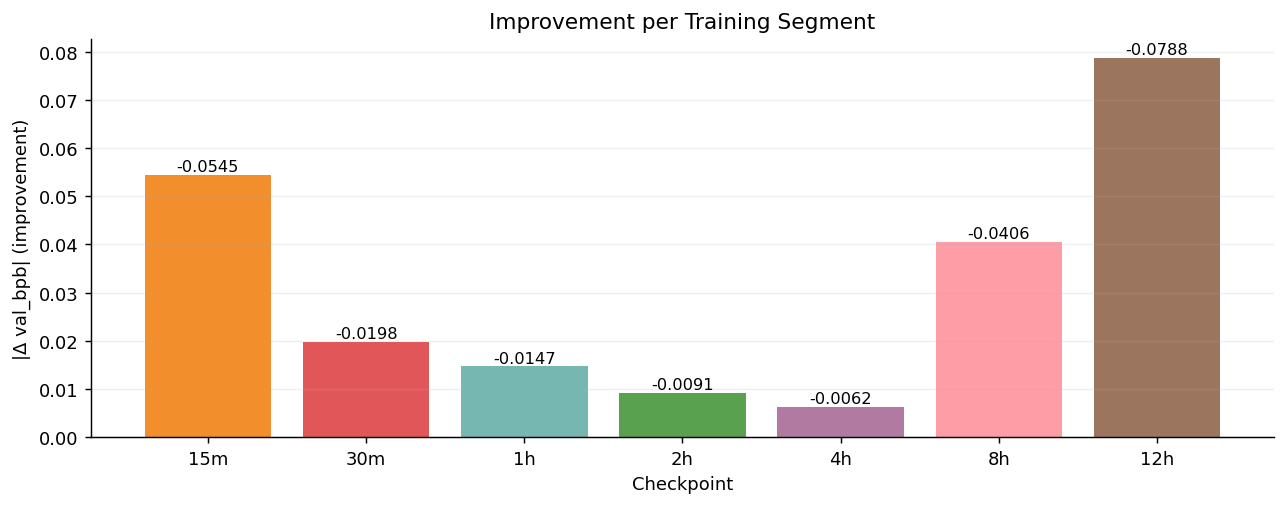

In [4]:
if not eval_df.empty and "val_bpb" in eval_df.columns:
    df = eval_df.dropna(subset=["val_bpb", "elapsed_min"]).copy()
    df["delta_bpb"] = df["val_bpb"].diff()  # change from previous checkpoint
    df["delta_min"] = df["elapsed_min"].diff()  # minutes between checkpoints
    df["bpb_per_min"] = df["delta_bpb"] / df["delta_min"]  # improvement rate

    print("Marginal improvement per checkpoint:")
    print(
        df[["label", "elapsed_min", "val_bpb", "delta_bpb", "bpb_per_min"]].to_string(
            index=False
        )
    )

    if len(df) >= 3:
        fig, ax = plt.subplots(figsize=(10, 4))
        valid = df.dropna(subset=["bpb_per_min"])
        bars = ax.bar(
            valid["label"],
            valid["delta_bpb"].abs(),
            color=[COLOR_OF.get(l, "#aaa") for l in valid["label"]],
        )
        ax.set_xlabel("Checkpoint")
        ax.set_ylabel("|Δ val_bpb| (improvement)")
        ax.set_title("Improvement per Training Segment")
        ax.grid(True, alpha=0.2, axis="y")
        for bar, (_, row) in zip(bars, valid.iterrows()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.0002,
                f"{row['delta_bpb']:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        plt.tight_layout()
        plt.savefig(RUN_DIR / "marginal_returns.png", bbox_inches="tight")
        plt.show()

## 4. LR Schedule Shape at Each Duration

Shows how the warmdown curve changes shape as total training time increases, using the current WARMDOWN_RATIO.

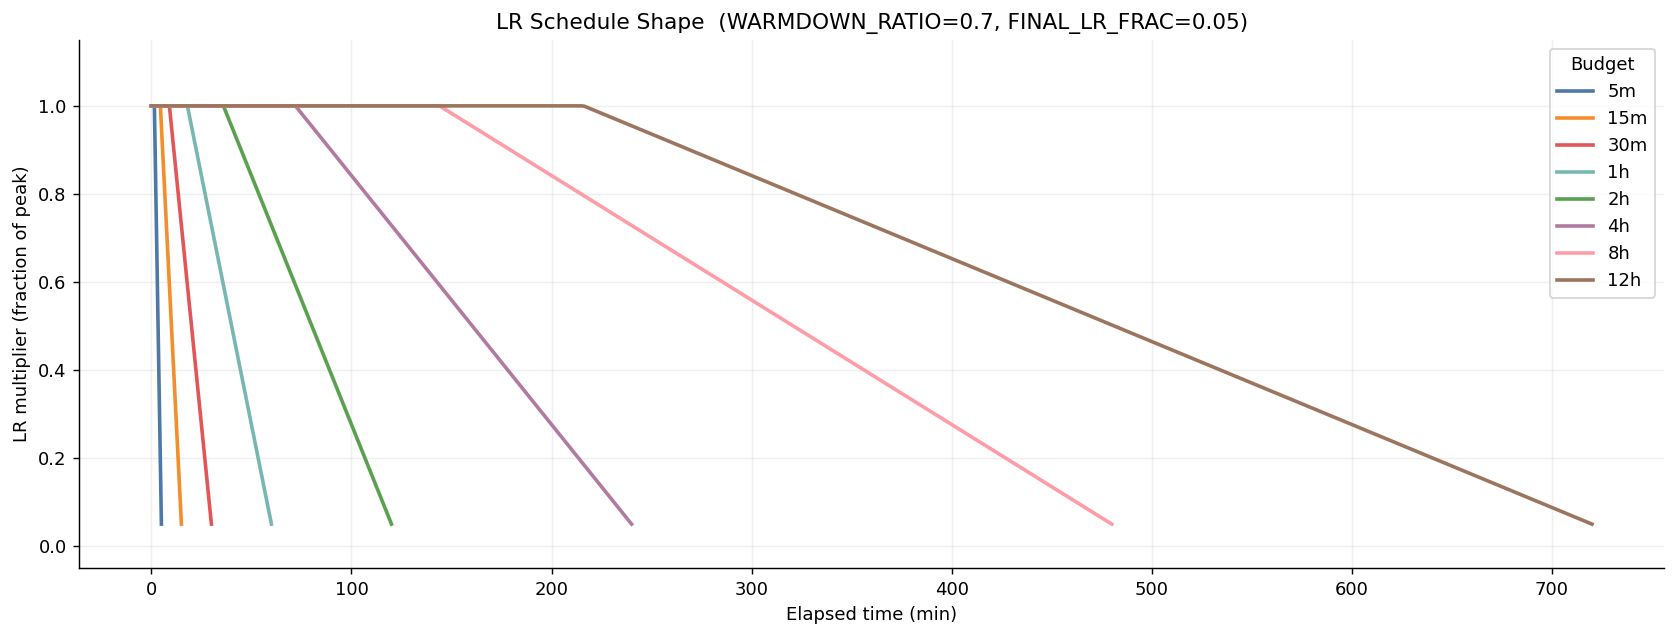

In [5]:
# Read current hyperparams from any available JSON sidecar
warmdown_ratio = 0.70
final_lr_frac = 0.05
for label in LABELS:
    meta_path = RUN_DIR / f"model_{label}.json"
    if meta_path.exists():
        m = json.loads(meta_path.read_text())
        hp = m.get("hyperparams", {})
        warmdown_ratio = hp.get("WARMDOWN_RATIO", warmdown_ratio)
        final_lr_frac = hp.get("FINAL_LR_FRAC", final_lr_frac)
        break


def lr_schedule(progress, warmdown_ratio=0.70, final_lr_frac=0.05, warmup_ratio=0.0):
    if progress < warmup_ratio:
        return progress / warmup_ratio if warmup_ratio > 0 else 1.0
    elif progress < 1.0 - warmdown_ratio:
        return 1.0
    else:
        cooldown = (1.0 - progress) / warmdown_ratio
        return cooldown + (1 - cooldown) * final_lr_frac


fig, ax = plt.subplots(figsize=(13, 5))
for label, color in zip(LABELS, COLORS):
    budget_s = LABEL_S[label]
    budget_m = budget_s / 60
    t = np.linspace(0, budget_m, 500)
    progress = t / budget_m
    lr = [lr_schedule(p, warmdown_ratio, final_lr_frac) for p in progress]
    ax.plot(t, lr, label=label, color=color, linewidth=2)

ax.set_xlabel("Elapsed time (min)")
ax.set_ylabel("LR multiplier (fraction of peak)")
ax.set_title(
    f"LR Schedule Shape  (WARMDOWN_RATIO={warmdown_ratio}, FINAL_LR_FRAC={final_lr_frac})"
)
ax.legend(title="Budget", loc="upper right")
ax.grid(True, alpha=0.2)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig(RUN_DIR / "lr_schedule.png", bbox_inches="tight")
plt.show()

## 5. Prompt Pack Outputs — Side-by-Side Comparison

In [6]:
PROMPT_NAMES = [
    "plain_continuation",
    "factual_fragment",
    "longitudinal_anchor",
    "structurally_awkward",
    "anomaly_lure",
    "signature",
    "continuation",
]


def parse_prompt_file(path):
    """Parse output/<label>_prompts.txt into a dict {prompt_name: completion_text}."""
    text = Path(path).read_text(encoding="utf-8")
    blocks = re.split(r"\n\[", text)
    results = {}
    for block in blocks[1:]:
        name_end = block.index("]")
        name = block[:name_end]
        body = block[name_end + 1 :]
        comp_match = re.search(r"COMPLETION:\s*(.*)", body, re.DOTALL)
        if comp_match:
            results[name] = comp_match.group(1).strip()
    return results


# Load all available prompt files
prompt_data = {}  # label -> {name -> text}
for label in LABELS:
    p = RUN_DIR / f"{label}_prompts.txt"
    if p.exists():
        try:
            prompt_data[label] = parse_prompt_file(p)
        except Exception as e:
            print(f"[{label}] could not parse: {e}")

print(f"Loaded prompt outputs for: {list(prompt_data.keys())}")

Loaded prompt outputs for: ['5m', '15m', '30m', '1h', '2h', '4h', '8h', '12h']


In [7]:
# Display side-by-side for each prompt type
available_labels = [l for l in LABELS if l in prompt_data]

for pname in PROMPT_NAMES:
    md = f"### `{pname}`\n\n"
    has_any = False
    for label in available_labels:
        text = prompt_data[label].get(pname, "*(not found)*")
        # Truncate for readability
        if len(text) > 600:
            text = text[:597] + "..."
        md += f"**{label}**\n> {text}\n\n"
        has_any = True
    if has_any:
        display(Markdown(md + "---"))

### `plain_continuation`

**5m**
> The old man walked slowly toward the river and has been a reality for many weeks, as many as 35 times asleep. The old man walked slowly in the river has already been restricted, and the people go untouched and turned into a place where this is not a place of mental health. (News. 2002-11)
The old man walked into a river with a slaughter turned into a series of river waves. The storm was not 11 years away by means of river waves. Despite this new man walked slowly. For times now, man walked into the rivers and flooded the waters of the river. He also found that man walked swords through the ...

**15m**
> The old man walked slowly toward the river and he was tilted to the shingles of the shingles of the shingles in the shingles.
The jaws of the shingles can vary very little from one place to the next. When young sons do shingles take place the shingles will take place, the shingles will wrap them in plastic bags on soaked shingles.
The shingles will wrap up and pull the shift towards shingles
Buders will wrap up and pull the jaws for shingles on all of the shingles.
The shingles will wrap toward the shingles in the shingles. The shingles can easily grab or lean the shingles on the shingle’s ...

**30m**
> The old man walked slowly toward the river and back to its slots in 2015. While we were young, you'll see a bit lighter.
Congriding in the water by the river, people may observe the old man walk on the water. However, it's best not in the Water with a drink.
The water in the city of Bernoucoe. There's more of a drink by the rambling of the street, which, for a longer period, be lesser and less aft to the road. The drink of the river could be the only drink more easily, allowing you to find more street signs which are the worst in the water.
Dr Duncan Powder, PhD, a senior scientist at Berno...

**1h**
> The old man walked slowly toward the river and dived from Julu, but did it because of wadding to an ice cream with no other nearby river was a large, dense lavajo earten off the coast of the Sierra Nevi and in some parts of the Sierra Michell.

Brittle the rivers in the Southern Nevi and rivers, when they were not wary of julu, to get stuck into julu, river waters.
There are many unrelenting river mouths for the river to travel north in inland, the ice can be seen and seen under an ice cold of a thousand earten off the Kerbalkankaraw.

The rocks are not waded and not rocked, such as the Cer...

**2h**
> The old man walked slowly toward the river and the sun was the newest of his day. His old man said he was a pretty new man and his gooey sorrow. He is now that his new man was the leader of the man and the man who was the father of the man.

Femari, a young man who has been growing and a father, was not the one the old man was at, and he was very father in his son who was the old man (hi). A man who is a young man, and he is not a new man or being in the new man. There he is also quite an asshole. In the sense he is a young man to be in the man, so what his son will never go into him was a ...

**4h**
> The old man walked slowly toward the river and averaged between 0.0-180 feet per second. That was a big question: Is the only theory for the Balkani? The original article, Paul E. L. L.. "When are the newest animals, they are always about the earth. The newest is the oldest the youngest. The animals can reach out of the river, and the newest is the young. The oldest goes to the river and the newest goes to the river.
The two species of the newest are the dolphins. The youngest goes to Paul E. L. L. L. Raising our own river, the oldest, and the newest they've ever seen, as well as the newest...

**8h**
> The old man walked slowly toward the river and was taking the walk toward some mimicking, one of the champions of banks and a 20-12-22, or six-12-22.
Hey I can see there Men, Logan, and hey, to tell him how you are wearing a sturdy sturd, like a boy, a sturdy man? Or how fast or how you can get it, or how you can pull your finger on where something looks like sturdy sturdy sturd? And to tell you how far out is, what is it's just a sturdy sturdy sturdy sturd?
One would be sarcoma if it's the skin of your sturdy skin. It's not the skin it it it it itn't it? It's the gender, its it itn't It it...

**12h**
> The old man walked slowly toward the river and had his eyes open because of his shallow endless water. His gnarled eyes kept flying and he flipped, while the others were standing waiting for them to flare out. The angler staring over the river seemed to make a head-up. As the others hadn't fled. As the angler waited for the water to approach those rivers, the angler began to question the reasoning behind the flow. The angler had to look at the muddy pile of water as much as possible with their eyes, which means that the muddler came out to do not want to be flopped down by other rivers or t...

---

### `factual_fragment`

**5m**
> The capital of France is Paris, and the population of Alkaloans over in Alkalo and Women is 3.5%. These are 4.6% of the Galaphi population, and the European population has received 9.9% of France. Many of them have adoptable 10% to 10-25% of the Galaphi population, while the population of those who had 0.9% of European settlement have been 2.09% of the Galaphi population in Alkalo.
Most Alkaloans are born who remain after
Robody, 74, 22 years of Pongki's disease is around 11-15 minutes. While this disease is in the early days of Alkaloans or the American population. In general for Galaphi p...

**15m**
> The capital of France is Paris, and the population of countries is taking part in different countries so as they need to pay attention. In Europe, country officials are increasingly exposed to capital of South Africa to a country (and are so vulnerable), the United States is being in the same danger as France has had not met countries with governments but has a big advantage on the population. In Europe, countries do not have any capital – they do not want the governments to be at peace, but they also need a lot of capital to do it. The economy needs to be constant. Therefore they need to d...

**30m**
> The capital of France is Paris, and the population of 150,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,000,00 each,000,000,000,000 and000,000,000,000,000,000,000,00,000,000,00000,000,000,500,000,000,000 deaths each,000 among them,000,000,000,
000,0,000,000,000,000,100,000,000,000,000,000,000,000,00000,

**1h**
> The capital of France is Paris, and the population of Paris is the Buddha, the Budalmanship, and Trucklifer.
With such large and fragile land, paris has taken a very high-level tourism across the nation. For Paris, Paris has been a very large country.
The Paris is also a very small paris.
We now know that Paris is quite large and very small and quite small, but has grown quite large, with relatively big and large number of large and fragile paris.
They have been pretty small.
The large number of paris is still huge, so far and very efficient in Paris from the Buddhist mountain. Its big size...

**2h**
> The capital of France is Paris, and the population of New Zealand is in Europe and it is becoming most important for the population's health. Land that provides a healthy economic opportunity is more of an exercise to preserve your nutritional well-being as well as strengthen your bones. This can affect your muscles and bones your bones. In fact, they are very similar – they are made from all of the ingredients with good cholesterol and nutrients, including calcium and phosphorous. These are the most important ingredients for all the health needed in most cases your bones will keep your min...

**4h**
> The capital of France is Paris, and the population of Nicoloria was the most commonly known and widely known. The capital of France, in the form of Iberian ranks of Iceland, is about 230 million, and has been considered to be the first known country to be known in the United States. The country, however, has never understood it, as it has been called the Civil War, and the capital of India has a very uncertain future. Significantly, the capital of Paris was, before, with the introduction of the Civil War, and the Berlin Pierra, Iceland’s Civil War, and the rise of ranks of Urban, the Mr. an...

**8h**
> The capital of France is Paris, and the population of England has the most impact on the environment of the nation's economy. The more than 50 percent of its meat consumed by poverty, the more food it goes. However, Paris has the most impact on the nation's economy as it grows increasingly fast. The nationwide consumption of meat was associated with a steady stream of 35,500 per kg of beef. It had the highest impact on its economics, which was associated with more food to the government and the economy. The capital on the nation has the most impact on its economical economics, but it also h...

**12h**
> The capital of France is Paris, and the population of the country is around 13 billion people. The country's major population is located over 65 billion, and of course the majority of the population is a poor minority. It's essential to understand this by choosing a poor country which is in need of a job.
None of the population is over-Economic. The government has a backing on international exports of export to areas where there were no population densities. In fact, the country currently has over 8 in 20 countries since it was built in the year 1909, and over a period of years it was in ne...

---

### `longitudinal_anchor`

**5m**
> In one sentence, the meaning of life is a term that occurs in an acceptable way, and that is a short term that requires a specific term used as the meaning in "effs" refers to the beginning of the term "lobby". This term is used in an opening called "lobby" refers to the term of ortechniques", although it is the term that involves the term that the term as "sexite."

Powerless Dehler - In Significance, the term is primarily refers to the term that focuses or refers to the phrase after termining or refersling the term. It refers to any term used as "rection term" defined in the term refers t...

**15m**
> In one sentence, the meaning of life is changed in time and time when it is impossible to solve for a reason or a lack of knowledge of the world, the definition of a 'productive succession' is so much inherent in the human mind. It comes down to that but when people are feeling a full truth, they are just giving away the potential to any particular concern and its challenges are not as likely in the future. To these criticisms, life is often misfortunate and undoubtedly we can be acknowledged that even the true truth is not quite obvious. But what is the meaning of God? For example, when Go...

**30m**
> In one sentence, the meaning of life is divided to three sentences:
- The most important is: Life is divided into the five sentences on how to describe the meaning of life, including the five sentences on his or her sentence. This sentence is about all sentence and circumstances that can be categorized to the meaning of life while also encourages the emotional reaction of people and society. In the context of sentence, it is divided into non-driving sentence and emotional responses to one sentence.
4 primary sentences for sentence sentence.
A speech essay @deas.
In a more comprehensive defi...

**1h**
> In one sentence, the meaning of life is intermovie. In this sentence the meaning of life history is intermovie. By the time when life history is interpreted. In the beginning, it was, when life history had happened to be interpreted by life and the life history period, the meaning of life history is interpreted.
The meaning of evolution is interchangeable. During the period when the meaning of life history influences the mean life of life in life and the mean lifetime. It was not interchangeable. It is interchangeable. Even though time history is interdivided for that purpose of life histor...

**2h**
> In one sentence, the meaning of life is sometimes in a particular way, and often happens when a given sentence often results in another form of life losing or losing his own or another way.
In addition to the sentence, it is a part of the word "there are only a few" in the body. In which an example, "there only need in medicine to become more viable in a disease in the body. In which cases, the only means it is necessary to live with one thing now. And, we have a second sentence because one thing is unawakened, because it does not go through the whole body.
There is one example, however the...

**4h**
> In one sentence, the meaning of life is called a family. In this study, 25 participants agreed to develop their business model by taking different kinds of money without having much trouble.

After determining the development of business models, they provided a starting point for a new platform (math of the game of "Tyramidae"). The new platform can make it easier for you to complete a project or start the project by adding your fundraiser to the game by adding your fundraiser.

A four-part story is a way to support people to believe in the opportunity, learn new skills in the way they inte...

**8h**
> In one sentence, the meaning of life is of itself; in some other contexts, life is an emerging topic, but it is a more comprehensive question. But how does life work? It is a specific topic. The question comes from the question: how does it work? Can one or more questions do this?

Acrosely Injured by Melbourne 1 in 2019, in question 7 of Sound's Winforward Family (WWWFF), University of Mississippi in 2005, is in fact the world's most comprehensive treatment for patients with diabetes in Canada's GI and Melbourne 2 years of Sound Medicine research. This book offers a starting point for disc...

**12h**
> In one sentence, the meaning of life is not explicitly stated and the message is always the same in all the sentences.
For Example 1, the first sentence of Soment 1 and Example 2 shows that no one is talking and we know that each sentence contains some sentence "give you a word". Because "give you a word and word" is simply called spontaneous "give you a word"
NarWali is a sentiment that is sometimes described as the "temporary" sentence of a spontaneous sentence.
If he is confused, there is a sentiment of the words "simple" and a statement of "go the day". The semantic sentiment implies th...

---

### `structurally_awkward`

**5m**
> Despite the fact that however, the reason why because the aging process isn't quite complicated. Craditional and traditional, the same basic concept is known as the fact that the process is more complicated for multiple processes, though most people might consider several different approaches. But in the sense of evolution of a larger process, most of the processes have been involved with this particular process. In other words, there is two important concept that, one would say that the process would involve different functions and methods for different kinds of processes. However, some su...

**15m**
> Despite the fact that however, the reason why because you may never fully understand the meaning of the most natural things is a problem. If you are looking for a problem on your face and if you try to get yourself and others on the road or have questions, we have you covered. Here we focus our eyes to the idea. From the way you want the most natural things to these things, and the way you want to know everything is from the wrong place that you want to get away from things. To go there, look for some things and even try to make things look like what you are in the eye.
A good way to go out...

**30m**
> Despite the fact that however, the reason why because of the notion of a single object (in general) that a single object is not a separate object is not a separate object. That is where it comes in from the concept of a design. For example, some modern design projects have several limitations. One is saying that there are several advantages of each object on the list that the object can be viewed as a separate object, which is based on the basic concept of the same object alone. In many ways, the concept of one object is still fixed. As a result, you may be not able to think about the same ...

**1h**
> Despite the fact that however, the reason why because it's impossible to maintain your health when it comes to achieving the right level of life is not to stay motivated at all.

While the best way for reaching your goal of life is to have some clear understanding of the things your goals are, it's not just focusing your goals. It's possible to maintain a good diet, exercise and be creative, it's your desire to exercise, or even your goals in everyday life.
Consider your goals as having a balance throughout your life; instead, include:

Determine the appropriate target within you. In contra...

**2h**
> Despite the fact that however, the reason why because a lot of people still have that say no to actually do any job they will do is that it is just to know it's not a fact and it just can also have a big impact on their caregivers.

When I look back at the fact there was a shortage of my family for a lot and a lot of people couldn't do the work right now, but there was another reason that I still need a fair amount of work now. It's that so because you cannot tell yourself the difference the thing is that there is not a whole fact and not that there is no right anyway. And there were a coup...

**4h**
> Despite the fact that however, the reason why because of gravity, is that you must still use a few different resources, so a lot of practice is necessary to stay in proper shape. Evolution and Honorige (grain, brain, head, neck and back ) does not equal the opposite problem of gravity, as they are used at both ends. However, evolution can be done to accommodate a lot of different problems, and a lot of specific problems may involve the use of a few different resources. So, when we have to say that your own "products" of mass mixtures, it might happen that's the theory or what you must know,...

**8h**
> Despite the fact that however, the reason why because many of us are not comfortable with nature, the benefits in such research are now much better. Apart from the fact that the evidence still isn't worthless, such research has shown that it helps in improving some kinds of health care through these treatments.
An interesting reason about the nature benefits is that animals have evolved as a natural source. As humans, it is impossible to understand that animals must never exist. Some studies highlight animals who have been seen as good as humans and have been seen as good nature. One of the...

**12h**
> Despite the fact that however, the reason why because of the hampon's high energy goal, they have achieved a very high energy goal with some very low incidences of this problem, but, aside from being a great source of power it also needs to be met with one goal.
The goal is just to ensure that the system can maintain even high energy levels until now.
What kind of system needs energy? To be able to run and use high energy resources, like the one mentioned above, our 18.0-20s, we will be able to have enough electricity in our homes this year. Even as we know, a great number of energy can pow...

---

### `anomaly_lure`

**5m**
> Ground control to Major Snorf, CMO, 125, and Ok, Os, Mercury

Cathe Serverages Credits 125, and Os are widely used for a number of the most widely used method of chemical processing in recent years, such as:
Prepared Carbonation: Brain control allows the conversion of a substance and a very low degree of use to remove the products in addition to other methods: to use the standard as a process that requires one-slorf perception of operation of a substance that is not applicable for any particular reason. To achieve such a complete object, consider using a combination of the process of the me...

**15m**
> Ground control to Major Snorf, Member
Dive: May 29, 2021

Memory

Memory: The Ergian Freedom Roveling in Ergian Goldenstein. 8

November 6, 2020 - Nova Scotland
Semory

Price
Image credit: Nova Scotland, Member

This year, the Principal Aquaria Bhazzamine and Member (Part Bandry and Member) the Ergian Freedom Roveling Association, Nova Scotland, Member. 4 (or 3) 4 (or 1) 4 (or 5) 5 (or 1) 6 (or 4) x 5 (orx) 8 (orx) x 5 (orx) 6 (orx)

**30m**
> Ground control to Major Snorf, CA

Brand Masterpiece, The Magic Masterpiece, The Magic Masterpiece, The Magic Masterpiece.

Masterpiece, The Magic Masterpiece, The magic Masterpiece, The Magic Masterpiece

Masterpiece, The Magic Masterpiece, The Magic Masterpiece, The magic Masterpiece, The magic Masterpiece, The Magic Masterpiece, The Magic Masterpiece, The magic mushroom, The Magic Masterpiece."

The downside of magic mushrooming:

The Magic Masterpieces, The magic Masterpiece, The magic mushroom, The magic Masterpiece, The Magic Masterpiece, The magic Masterpiece, The magic mushroom, The...

**1h**
> Ground control to Major Snorf, Friends, or Movies can be in action. Around the world, the use for a ground control to be applied is known to be effective at bringing ground to your home.
What is the ground control to Major Snorf?
The ground control is a ground control that connects ground to the foundation of ground, ground, the ground, your home, or the landscape. The ground control has ground, and grounds into ground is connected to the ground by an integrated buried ground.
What are ground control to Majorie ground control?
The ground controlled ground control is an ground control that c...

**2h**
> Ground control to Major Snorf, a species of apeptoid species (Frexelo, a genus of flowering species; Anapisia species) and Sonus (especially sapipterus species), although species of anthoplasts or royalactus species (Frexelo, a genus); Aquistidodae species species (Frexelo) to the Tribeus species, although it is widely accepted to be considered more broader species as they may not be considered.

What Are Its Importance and What Are the Types of Species? (Trapping, Sparrow, Maeus)?

Friminism is (troups or scopes) which is a species of a species. These species, along with the male of its mu...

**4h**
> Ground control to Major Snorf, Shakeson or Fruit Creek Snorf, Bobby Snowmen, and Bobcat License. Also known as the fierch, Jenna Lorse, Sherman, Romania, Swedish, and Turkey, these small skies do not belong in the class, rather they are the class on the same way: Hadiard Gols, Riches. They are the small and one that we usually find their own, but the other of our own. The bountiful fierchings, of the Santica and Toyce, are the fierchings of this class, and is an articulation of how it has evolved that the common and endangered species of snake, Jenna, and Turkeys are related in the field. T...

**8h**
> Ground control to Major Snorf, Korla Mj. Pedes

Norie Snake Shorthy

Ever wondered whether a single single slate cutter will actually bake? The answer is: Ground control can be used to shape the cutter's workout, control its thickness, and cutter's shape is known for its small size and long stature. The thickness of a single single single slate's cutter will determine if it's going to cut down on its cutting speed, and make it look more like the bake-cut version is being used (one double double double double double double double double double single single double single double double single...

**12h**
> Ground control to Major Snorf, Frosted, Pyramids, Fly, and Common Core: Sticky Layers, Wheels, Ground Fibros (Drawings, Signs, Symbols, Fabrications, Lights, Courses, Navigations, Opportunities, Opportunities, Line, Navy and Pelleton)

Pyramids are the most common, except when most patients have a small bowel movement in their backyards, and they are able to get comfortable in their quest after sitting or lying down.

But they are also able to get a full range of movements at once. Most of the time, this is especially true in the wild and there is no demand for animals to eat it.

If they a...

---

### `signature`

**5m**
> Once upon a time there was a small town among the mains and villages of Maine, there was no actual production. The first major problem for this time since then, as the production rate increases, the amount of production is increasing again. At the moment, people who worked hardly towards the village were very well-known and often since they were being put in an ever-known reason being lost. Some places were not in the country to live in or on their own. The main reason why this time has been the production? The country is usually there before the villages for use, at the groovey store here ...

**15m**
> Once upon a time there was a small swaying of small-less soft-tipped glow-heads, such as an upcoming socket, that the sways were on the ground to release. On the other hand, there was a small footprint among the sways left to play and the sways left were smaller, allowing the platter to throw off the grass or shrub. However, this was not true enough to do the sways until it wasn't enough to bend a lot of time until it did a few things quite a bit different than just a tiny piece! Here's what we've got about it:

Breathing:

Difficulty breathing - a pleasurable feeling - itching – itching

b...

**30m**
> Once upon a time there was a small town in the Bugar District where a small town was named and was one of the most incredible and beautiful locations out there.

One of the first big cities in the town of Campbell (Combine, France's second town) where people in the community are still learning to recognize the beautiful little town of Camera, Naples, and more with their unique talents to hear the community.

This town is focused on exploring the gross world around the town of Camera. This type of town is the largest of all towns who live up to its name.

The town offers several unique photo...

**1h**
> Once upon a time there was a small town filled with a large town in Batanaval, M.I. Rachel lived in Bathan, Missouri. Rachel called the Father's Four Billers, who called Four Biller. That's filled with the stars and galaxies that could close the globe even when they finally returned to Batanaval. He created three great cities around the world who took the great deal and now known as M.I. St. Vanu and Rhill, and began in Brusades, with an estimated 564 million people and about 2 million visitors worldwide. As a result he believeded, he was still so we couldn't see. While he loved hearing – s...

**2h**
> Once upon a time there was a small bustling town named Haywonder, Martir Feder decided to join the next adventure. One day they took a while, they went to town and friends who loved it. A friend asked me if I had some help, either through a visit from another location or simply someone asking me for a name. How did I send my buddies to her favorite places? These friends couldn't seem like they couldn't believe what was done as they were too much too busy or causing someone misunderstood or unpleasant experiences in the same spot. By speaking of loud noises, their voice grew worse. As they s...

**4h**
> Once upon a time there was a small, simple, yet very large group of plants, there was a complete whole called tropospucantalium which is a part of the ecosystem for plantation, thus allergy to plantation from all kinds of species, including other taxa, such as the darts and porosomales.
We can read what this article calls something "into," as well as how we understand how the plant affects the environment and we can understand why plants may be disturbances, if they are not properly disturbed by their plants and are allowed to flourish in a variety of environment conditions. The plant also ...

**8h**
> Once upon a time there was a small brother of John Dharma – one important wife for both parents. Dharma began when his wife became a romantic parent after he discovered that he was fathering sons. At that age, his brother died in his own life. One week, D. Harma continued her personal life because he had not been wounded by anyone else but was not a parent.
One day, when he was old enough to join him for being out at sea at drafts, the king always wondered if they had to be raised and raised enough to be living together. D. Harma became a romantic parent for both parents of people born on S...

**12h**
> Once upon a time there was a small town named Alice called Alice's Royalty, a wise couple. It seemed easy to see everything happening now, but what happened before was that they didn't come up with new ways to teach them. One day Alice sir Jonas Garrett, who was a friend of mine, had been asked, "How do you teach children at Alice?"

Garrett greeted her sister, "Well sowed seeds for our children!" He approached the whole place where Alice became the first youngest mom of life; they thought it was always true they even were, "Is the same gospel? How do they grow?"

As they started their morn...

---

### `continuation`

**5m**
> The instructions were clear until line seven:10 -32/2
2019/2018· The instructions made for the first time when the instructions went so that it didn't take up at the moment to go. Eitherto do the work. Slowly release the instructions down again, it may feel that you'll just be able to find the correct instructions.
The instructions made in 3 minutes should the instructions to keep the instructions in mind when releasing the instructions into the instructions. I didn't put it apart so that it's pretty much easier, so how time it's been done?
How do you change how the assembly of instructions...

**15m**
> The instructions were clear until line seven: 12: 13: 12: 15: 15: 15: 15: 17: 15: 17: 16: 15: 15: 17: 15: 17: 15: 7: 16: x: 15: 17: 15: 17: 17 (: 15: 17: 17: 16: 17: 15: 16: 17: 17: 16: 18: 18: 17:: 18: 17: 17: 17: 17: 17; 18: 17: 17: 15: 15: 18: 18: 18: 17: 17: 17: 17: 16: 15: 15: 17: 17: 21: 17: 17: 17: 17: 

========================================================================

**30m**
> The instructions were clear until line seven: 4296° or 5084°; 5084°.
The more complicated instruction made by reading this post was to use the dictionary to tell you how much difference they have received for your school, according to the instructions provided by the instructions.
This type of instructions provided the instructional instructions that you were written on. It also had instructions when taking instructions, as this was a complete instructions. It also also had instructions on which instructions were needed when the instructors were given instructions.
This instructions are int...

**1h**
> The instructions were clear until line seven: 1,2,3
The number of 5,135 shows the number of 7.36.
They were number-blooded, and their length is still pretty much guaranteed. The code is very smooth. The code is 2x4.
2
The numbers were number-blobal.
The first count of 5 numbers are number of number-blooded, and numbers are numbers are two-4.3 or four.3 numbers are number of number numbers, respectively. The two number numbers of numbers are number-blooded, and numbers number are of numbers number-blooded.
There are number numbers number numbers number six number number numbers are number-bl...

**2h**
> The instructions were clear until line seven:59. The instructions were clear, clear, clear, and clearly marked. After detailed instructions, red lines drawn lines carefully drawn on the center of the lines line along the top of the line line line line line line line line lines line line line lines line line lines line line line lines line line lines lines horiz line line line lines line lines line line line lines lines lines drawn line text lines lines drawn drawn linelines lines drawn graph line line line lineline lines drawn Draw lines lines drawn lines lines line lines lineslines lines l...

**4h**
> The instructions were clear until line seven: 1. 3. 9.
Computer and smart computer are the key elements of a computer software. The primary computer programs have a number of instructions with functions
programs that allow computers to get started in a wide range of applications. For example, when it comes to building cache and cookware, there are a vast number of products on record (such as cookware or cookieware). To check these instructions can be downloaded or checked to the right to start.
Interpreting the instructions
Finding the desired "shape" has been the result.
When you are looki...

**8h**
> The instructions were clear until line seven:19; in the words, the instructions were not read. The instructions were clear, but the instructions were just descriptive (for example, "1-2"). In
Subscribe to the Insta and Discussion channel, and the 2004 version was a dotted instruction. The instruction set is 1) In the previous manual, the instructions were clear and clear with the instructions. If you didn't make this instructions about, the instruction was clear (that had a hard time understanding the instructions); but if it were clear then it was clear to the instructions, the instruction...

**12h**
> The instructions were clear until line seven: 5 S. (Margaret-Stadtz, L.V.). The result is a clear line of instructions in the direction not on either side, with the same number of rows as the horizontal line.
Subject: BM
For example, the MRC and WEB (Monad Combined Method) were constructed for the same sequence but were more complicated and require more or less training than the LRC method.
For example, it was possible that the 1-16 rows were already created in the same sequence, for each of the nine rows, for the next row, for that particular order, for the next row.
With the two sets of s...

---

## 6. Text Quality Metrics

Automatic proxies for qualitative change. These are rough signals, not ground truth.

Mean across all prompts per checkpoint:


,rep_onset_word,clean_span,rep_rate,sent_completion,ttr,avg_sent_len
label,,,,,,
5m,105.000,105.000,0.010,0.831,0.519,23.586
15m,76.429,76.429,0.037,0.700,0.472,32.186
30m,71.714,71.714,0.088,0.706,0.412,19.429
1h,98.286,98.286,0.026,0.891,0.475,15.114
2h,113.571,113.571,0.029,0.846,0.480,26.229
4h,126.000,126.000,0.009,0.872,0.553,20.671
8h,81.286,81.286,0.062,0.885,0.492,20.614
12h,133.429,133.429,0.004,0.881,0.601,19.429


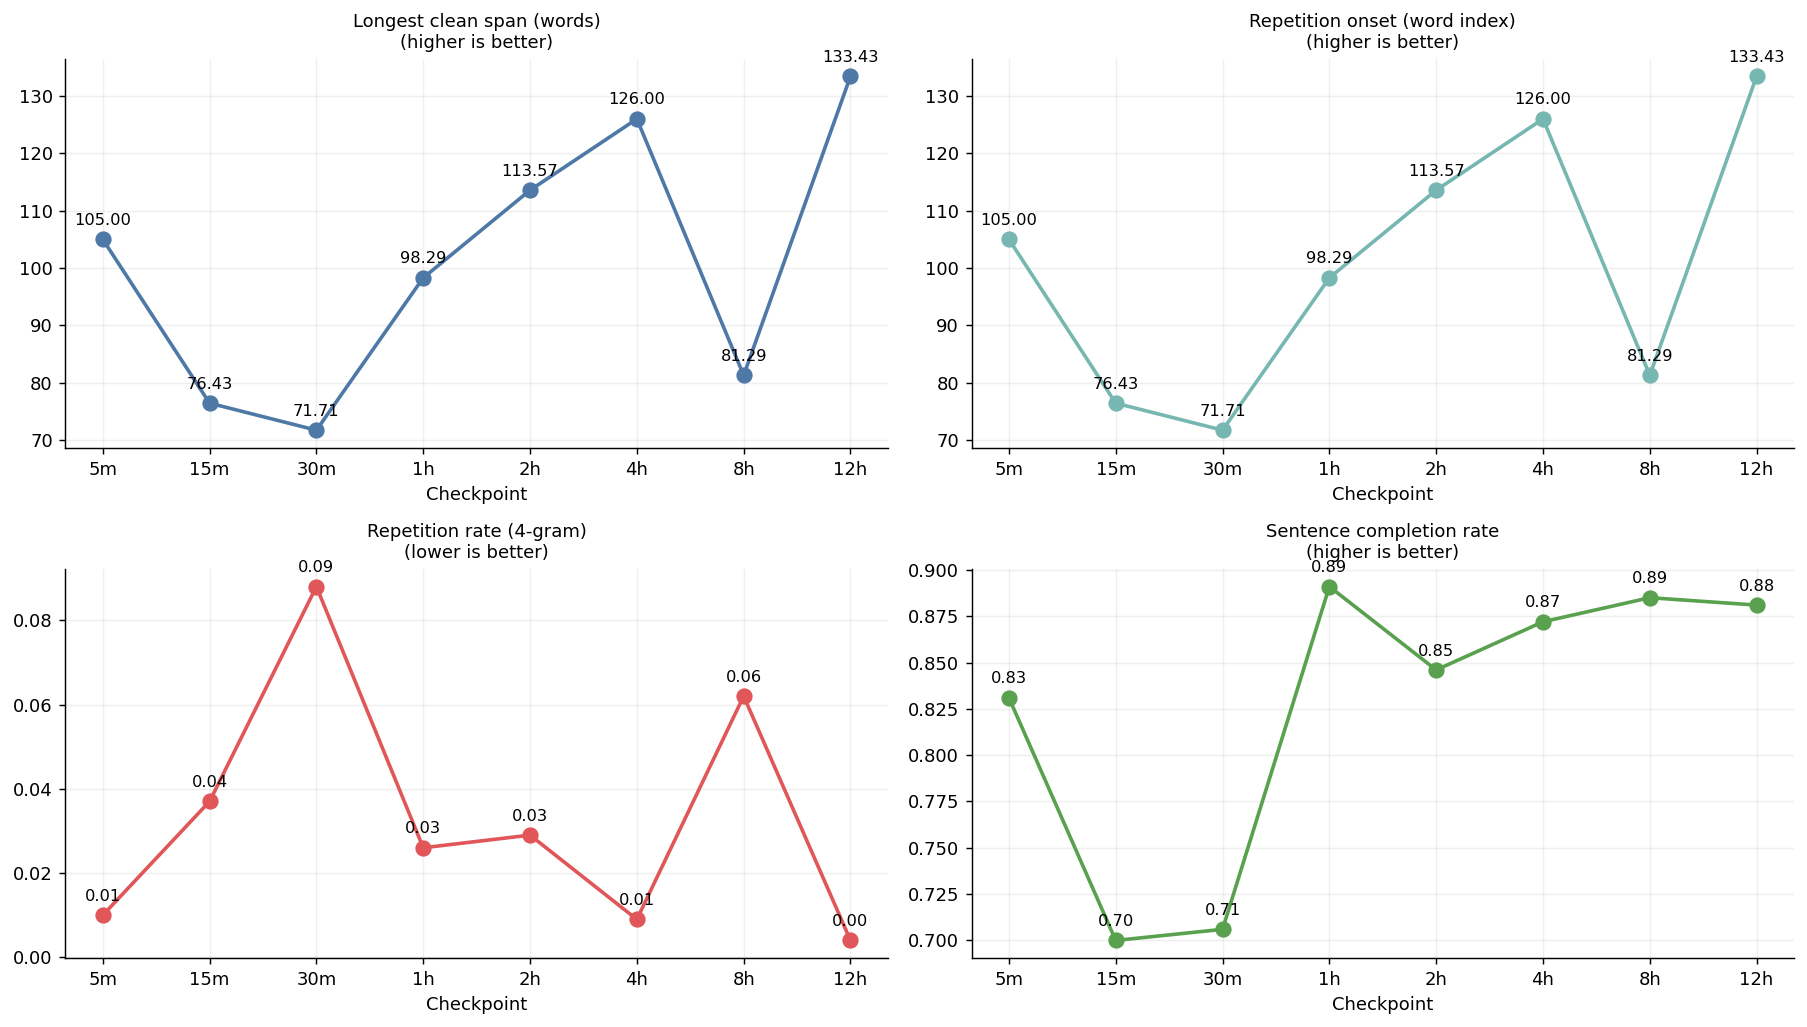

Saved output/text_metrics.png


In [8]:
def repetition_onset(text, ngram=4):
    """Word index of the first repeated n-gram. Returns None if no repetition."""
    words = text.lower().split()
    seen = {}
    for i in range(len(words) - ngram + 1):
        g = tuple(words[i : i + ngram])
        if g in seen:
            return i
        seen[g] = i
    return None


def longest_clean_span(text, ngram=4):
    """Number of words before the first repeated n-gram (= repetition_onset, or full length)."""
    onset = repetition_onset(text, ngram)
    words = text.split()
    return onset if onset is not None else len(words)


def repetition_rate(text, ngram=4):
    """Fraction of n-grams that are repeated."""
    words = text.lower().split()
    if len(words) < ngram + 1:
        return 0.0
    grams = [tuple(words[i : i + ngram]) for i in range(len(words) - ngram + 1)]
    return 1 - len(set(grams)) / len(grams)


def sentence_completion_rate(text):
    """Fraction of sentence-like units ending with . ! ? — proxy for syntactic tidiness."""
    units = re.split(r"(?<=[.!?])\s+", text.strip())
    if not units:
        return 0.0
    complete = sum(1 for u in units if re.search(r"[.!?]$", u.strip()))
    return complete / len(units)


def type_token_ratio(text):
    """Lexical diversity — length-dependent; use as directional signal only."""
    words = re.findall(r"\b\w+\b", text.lower())
    return len(set(words)) / len(words) if words else 0.0


def avg_sentence_length(text):
    sentences = re.split(r"[.!?]+", text)
    lengths = [len(s.split()) for s in sentences if s.strip()]
    return np.mean(lengths) if lengths else 0.0


# Compute metrics per label per prompt
metric_rows = []
for label in available_labels:
    for pname, text in prompt_data[label].items():
        onset = repetition_onset(text)
        metric_rows.append(
            {
                "label": label,
                "prompt": pname,
                "rep_onset_word": onset if onset is not None else len(text.split()),
                "clean_span": longest_clean_span(text),
                "rep_rate": round(repetition_rate(text), 4),
                "sent_completion": round(sentence_completion_rate(text), 3),
                "ttr": round(type_token_ratio(text), 4),
                "avg_sent_len": round(avg_sentence_length(text), 1),
            }
        )

if metric_rows:
    mdf = pd.DataFrame(metric_rows)
    summary = (
        mdf.groupby("label")[
            [
                "rep_onset_word",
                "clean_span",
                "rep_rate",
                "sent_completion",
                "ttr",
                "avg_sent_len",
            ]
        ]
        .mean()
        .round(3)
    )
    summary = summary.reindex([l for l in LABELS if l in summary.index])
    print("Mean across all prompts per checkpoint:")
    display(summary)

    # Plot: the four most diagnostic signals
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    plots = [
        ("clean_span", "Longest clean span (words)", "#4e79a7", "higher is better"),
        (
            "rep_onset_word",
            "Repetition onset (word index)",
            "#76b7b2",
            "higher is better",
        ),
        ("rep_rate", "Repetition rate (4-gram)", "#e15759", "lower is better"),
        ("sent_completion", "Sentence completion rate", "#59a14f", "higher is better"),
    ]
    for ax, (col, title, color, note) in zip(axes.flat, plots):
        ax.plot(
            summary.index,
            summary[col],
            marker="o",
            color=color,
            linewidth=2,
            markersize=8,
        )
        for x, y in zip(summary.index, summary[col]):
            ax.annotate(
                f"{y:.2f}",
                (x, y),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
            )
        ax.set_title(f"{title}\n({note})", fontsize=10)
        ax.set_xlabel("Checkpoint")
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(RUN_DIR / "text_metrics.png", bbox_inches="tight")
    plt.show()
    print("Saved output/text_metrics.png")

## 7. Qualitative Notes

Per-run scoring tables and narrative observations now live next to the run data, in `<run_dir>/qual-notes.md`. The rolling cross-run analysis (plateau evidence, warmdown findings, decisions for the next night) stays in [`docs/phase2-developmental-study.md`](docs/phase2-developmental-study.md). Memorable generations are collected in [`docs/curios.md`](docs/curios.md).

The current run's `qual-notes.md` is rendered below; if `BASELINE_DIR` has one, it is shown too for side-by-side comparison. If a run has no `qual-notes.md` yet, the cell prints a short hint instead.


In [9]:
def _show_qual_notes(run_path, heading):
    notes = Path(run_path) / "qual-notes.md"
    if not notes.is_file():
        display(Markdown(f"_No `qual-notes.md` in `{run_path.name}` yet._"))
        return
    display(Markdown(f"### {heading} — `{run_path.name}`"))
    display(Markdown(notes.read_text(encoding="utf-8")))


_show_qual_notes(RUN_DIR, "Current run")
if BASELINE_DIR is not None:
    _show_qual_notes(BASELINE_DIR, "Baseline")

### Current run — `2026-04-17_12h_run`

# Qualitative Notes — 2026-04-17 12h Extended Run

Detailed narrative analysis (plateau evidence, warmdown gap, decisions for next night) lives in the rolling log: [`docs/phase2-developmental-study.md` — Phase 2b section](../../docs/phase2-developmental-study.md#phase-2b-12h-extended-run-2026-04-18).

Memorable generations from this run are collected in [`docs/curios.md`](../../docs/curios.md).

## Scoring

Scales are defined in [`program.md`](../../program.md).

Columns 5m–4h carry over from the 2026-04-17 phase2 baseline for reference. Note that the 12h run's own 5m–4h checkpoints share the 12h LR schedule (still at full LR at 4h), so their prompt-output quality is not directly comparable to the dedicated baseline — re-score this run's own 5m–4h columns when a same-schedule comparison is needed. Columns 8h and 12h are specific to this run; fill in after reviewing the `<label>_prompts.txt` files.

| Prompt | Metric | 5m | 15m | 30m | 1h | 2h | 4h | 8h | 12h |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| plain_continuation | coherent span (1–5) | 1 | 1 | 1 | 2 | 1 | 2 |  |  |
| plain_continuation | syntax stability | poor | mixed | mixed | poor | mixed | good |  |  |
| plain_continuation | prompt adherence | poor | poor | poor | poor | poor | poor |  |  |
| factual_fragment | specificity vs sludge | filler-heavy | filler-heavy | filler-heavy | filler-heavy | filler-heavy | filler-heavy |  |  |
| factual_fragment | prompt adherence | weak | weak | weak | weak | weak | weak |  |  |
| longitudinal_anchor | coherent span (1–5) | 1 | 2 | 1 | 1 | 2 | 2 |  |  |
| longitudinal_anchor | specificity vs sludge | filler-heavy | filler-heavy | filler-heavy | filler-heavy | filler-heavy | mixed |  |  |
| structurally_awkward | syntax stability | good | good | mixed | mixed | mixed | mixed |  |  |
| structurally_awkward | prompt adherence | weak | weak | weak | weak | weak | weak |  |  |
| anomaly_lure | weirdness retained | high | high | high | high | high | high |  |  |
| anomaly_lure | interestingness | none | mild | mild | notable | notable | mild |  |  |
| signature | coherent span (1–5) | 2 | 2 | 3 | 2 | 1 | 2 |  |  |
| signature | repetition onset | none | early | none | none | none | none |  |  |
| continuation | coherent span (1–5) | 1 | 1 | 1 | 1 | 1 | 1 |  |  |
| continuation | prompt adherence | 1 | 1 | 1 | 1 | 1 | 1 |  |  |
| **ALL** | **overall interestingness** | mild | mild | mild | notable | notable | notable |  |  |


_No `qual-notes.md` in `2026-04-17_phase2_baseline` yet._